# Assignment 1: Question 2
**Course:** Machine Learning  
**Student:** Navneet Das  
**Date:** july 2026  

---

## Polynomial Regression — Modeling Plant Growth Curves

### Objective
> Fit a polynomial regression model to capture the nonlinear growth pattern of a plant over time.

<div class="alert alert-warning">
<b>Alert!</b> The give dataset could not be found heance i have used the <b> Position_Salaries.csv </b> dataset in it
</div>

step 1: Load the dataset from plant_growth.csv.  

In [1]:
import pandas as pd
data = pd.read_csv("./Data/Position_Salaries.csv",usecols=["Level","Salary"])
data.shape,data.tail()

((10, 2),
    Level   Salary
 5      6   150000
 6      7   200000
 7      8   300000
 8      9   500000
 9     10  1000000)

step 2: Fit a degree-3 polynomial: y = β0 + β1x + β2x² + β3x³  

In [2]:
xtrain=data[["Level"]]
ytrain=data["Salary"]

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

my_pipeline=make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

display(my_pipeline)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('linearregression', LinearRegression())])

In [4]:
my_pipeline.fit(xtrain,ytrain)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('linearregression', LinearRegression())])

step 3: Also fit a simple linear regression model on the same data for comparison. 

In [5]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(xtrain,ytrain)

LinearRegression()

step 4: Compare the polynomial regression curve with the linear regression line. 

In [6]:
from sklearn.metrics import r2_score
model_r2_score = r2_score(ytrain,my_pipeline.predict(xtrain))
linear_model_r2_score = r2_score(ytrain,linear_model.predict(xtrain))

print(f"the r2 score of polynomial curve is {model_r2_score} or {model_r2_score*100:.2f}%")
print(f"the r2 score of linear line is {linear_model_r2_score} or {linear_model_r2_score*100:.2f}%")

the r2 score of polynomial curve is 0.9812097727913365 or 98.12%
the r2 score of linear line is 0.6690412331929895 or 66.90%


step 5: Plot both curves on the same graph, overlaid on the scatter of actual data points.  

In [7]:
# numpy.linspace() to generate smooth x-values for plotting the curve
import numpy as np
x_smooth = np.linspace(xtrain.min(),xtrain.max(),100).reshape(-1,1)
y_smooth = my_pipeline.predict(x_smooth)

c:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


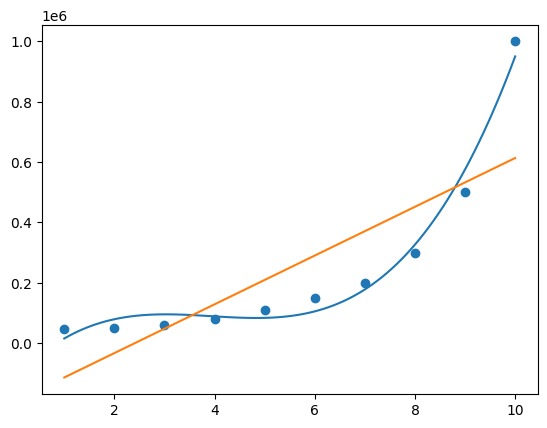

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(xtrain,ytrain)
plt.plot(x_smooth,y_smooth)
plt.plot(xtrain,linear_model.predict(xtrain))
plt.show()

step 6: Comment on which model fits the data better and why.  
Answer: Polynomial regression model fit the curve best with the accuracy of **98.12%** as compaire to Linear Regression model which has a accuracy of only **66.9%**

In [18]:
# Finding Intercept and coeffecent of the polynomial moded
my_pipeline.named_steps["linearregression"].coef_,my_pipeline.named_steps["linearregression"].intercept_

(array([     0.        , 180664.33566437, -48548.95104896,   4120.04662005]),
 -121333.33333338297)

### Conclusion
1. **Model Equation:**  
    The simple polynomial regression model was successfully trained with the equation:  
    $$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3$$
    $$\text{Price} = -121333.33 + 0 + (180664.33 \times \text{Level}) + (-48548.95 \times \text{Level}^2)+(4120.04 \times \text{Level}^3)$$
   * **Slopes** ($\beta_1 \approx 0$,
   $\beta_2 \approx 180664.33566437$,
   $\beta_3 \approx  -48548.95104896$,
   $\beta_4 \approx 4120.04662005$)
   * **Intercept** ($\beta_0 \approx 121333.33333338297$)
2. **Model Evaluation:**  
    |model  |R2 score|
    |-------|--------|
    |Polynomial regression|**0.9812097727913365**|
    |Linear regression|**0.6690412331929895**|
